=== Selección de target ===
Target: 164_bin
Mapping usado (-> 0/1): {'164 < 654.0': 0, '164 >= 654.0': 1}
(Nota) Target generado automáticamente por mediana de la última columna numérica.

===== Resultados (Práctica 7) =====
Features usadas (1): ['493782']
NLL final: 17.660421
Accuracy (umbral 0.5): 82.00%
Pesos (w):
  w[intercepto] = 1.327401
  w[493782] = 5.304940


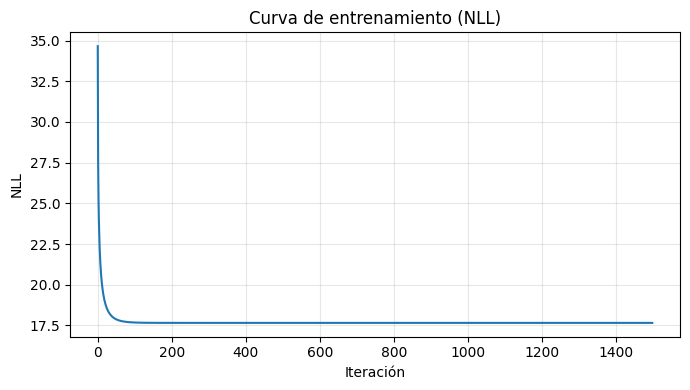

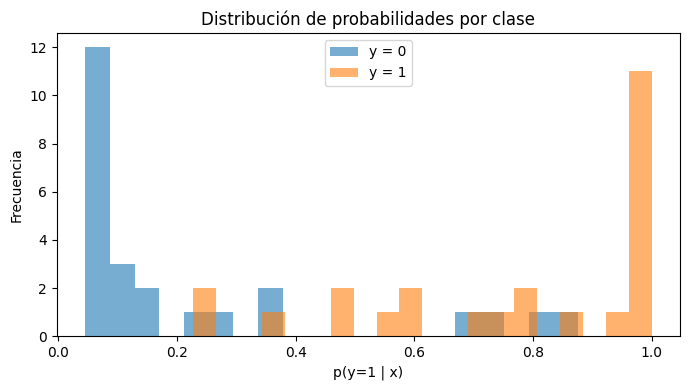

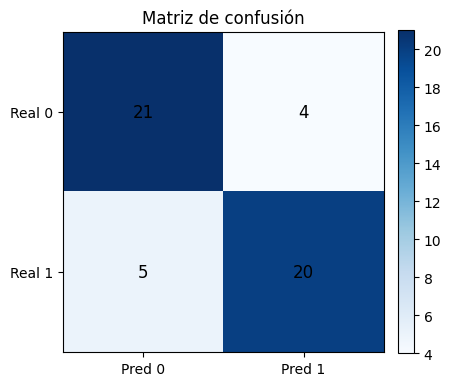

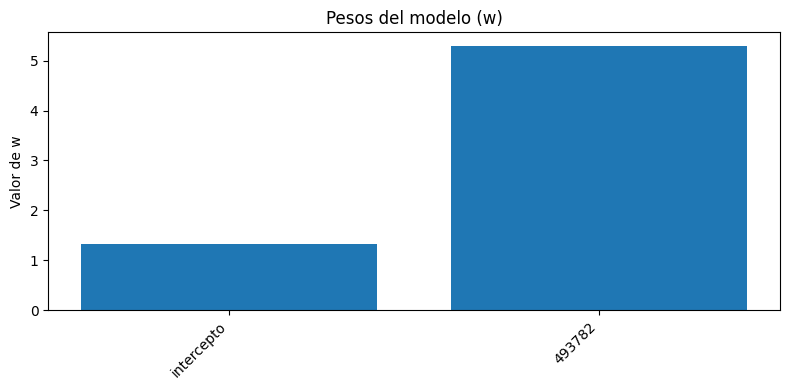

In [3]:
# Práctica 7 – Regresión logística con Negative Log-Likelihood (NLL) y Gradiente Descendente (GD) analítico
# Autor: Christian Luna (CLUNA)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Cargar datos
# =========================

path = "https://raw.githubusercontent.com/ChristianLuna1/tesis-maestria/refs/heads/main/Machine_Learning/DatosPractica1CLuna.csv"

df = pd.read_csv(path)

# =========================
# 2) Seleccionar/MAPEAR el TARGET
# =========================
force_target_col = None  # ejemplo: "Outcome"

mapping_manual = None

def detectar_target_binario(dataframe: pd.DataFrame):
    # (a) columnas numéricas que ya sean 0/1
    num_cols = dataframe.select_dtypes(include=[np.number]).columns.tolist()
    for c in num_cols[::-1]:  # pruebo de derecha a izquierda (suele venir al final)
        vals = pd.unique(dataframe[c].dropna())
        try:
            cast_vals = pd.Series(vals).astype(int).unique()
            if set(cast_vals) <= {0, 1} and len(cast_vals) == 2:
                return c, None  # ya es 0/1
        except Exception:
            pass

    # (b) cualquier columna con EXACTAMENTE 2 categorías distintas (no nulas)
    for c in dataframe.columns[::-1]:
        vals = pd.unique(dataframe[c].dropna())
        if len(vals) == 2:
            # mapeo en orden de aparición a {0,1}
            return c, {vals[0]: 0, vals[1]: 1}

    return None, None

target_col = None
mapping_usado = None

if force_target_col is not None:
    target_col = force_target_col
    if mapping_manual is not None:
        df[target_col] = df[target_col].map(mapping_manual)
        mapping_usado = mapping_manual
    else:
        vals = pd.unique(df[target_col].dropna())
        try:
            cast_vals = pd.Series(vals).astype(int).unique()
            if set(cast_vals) <= {0, 1} and len(cast_vals) <= 2:
                df[target_col] = df[target_col].astype(int)
                mapping_usado = None
            else:
                if len(vals) == 2:
                    mapping_usado = {vals[0]: 0, vals[1]: 1}
                    df[target_col] = df[target_col].map(mapping_usado)
                else:
                    raise ValueError("El target forzado no es binario (tiene != 2 valores).")
        except Exception:
            if len(vals) == 2:
                mapping_usado = {vals[0]: 0, vals[1]: 1}
                df[target_col] = df[target_col].map(mapping_usado)
            else:
                raise ValueError("El target forzado no es binario (tiene != 2 valores).")
else:
    target_col, mapping_usado = detectar_target_binario(df)
    if target_col is not None:
        if mapping_usado is not None:
            df[target_col] = df[target_col].map(mapping_usado)
        else:
            df[target_col] = df[target_col].astype(int)

# Si NO hay target binario, lo genero automáticamente desde la última columna numérica
auto_target = False
if target_col is None:
    num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols_all) == 0:
        raise ValueError("No hay columnas numéricas en el dataset para generar un target binario.")
    base_col = num_cols_all[-1]
    med = float(df[base_col].median())
    target_col = f"{base_col}_bin"
    df[target_col] = (df[base_col] >= med).astype(int)
    mapping_usado = {f"{base_col} < {med}": 0, f"{base_col} >= {med}": 1}
    auto_target = True

print("=== Selección de target ===")
print(f"Target: {target_col}")
print("Mapping usado (-> 0/1):", mapping_usado if mapping_usado is not None else "ya era 0/1")
if auto_target:
    print("(Nota) Target generado automáticamente por mediana de la última columna numérica.")

# =========================
# 3) Preparar X (features numéricas) e y
# =========================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c != target_col]

if auto_target:
    base_original = target_col.replace("_bin", "")
    if base_original in feature_cols:
        feature_cols.remove(base_original)

if len(feature_cols) == 0:
    raise ValueError("No hay columnas numéricas para X (aparte del target).")

X_raw = df[feature_cols].to_numpy(dtype=float)
y = df[target_col].to_numpy(dtype=float).reshape(-1, 1)

# Normalización z-score (mejora estabilidad numérica)
X_mean = X_raw.mean(axis=0, keepdims=True)
X_std = X_raw.std(axis=0, keepdims=True)
X_std[X_std == 0] = 1.0
Xz = (X_raw - X_mean) / X_std

# Intercepto
ones = np.ones((Xz.shape[0], 1))
X = np.hstack([ones, Xz])   # shape (n, d+1)
n, d = X.shape

# =========================
# 4) Modelo: sigmoide, NLL y gradiente (derivados a mano)
# =========================
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def nll_and_grad(w, X, y):
    """
    NLL(w) = -sum[ y*log(p) + (1-y)*log(1-p) ], con p = sigmoid(Xw)
    ∇NLL(w) = X^T (p - y)
    """
    z = X @ w
    p = sigmoid(z)
    eps = 1e-12
    p_clip = np.clip(p, eps, 1 - eps)
    nll = -np.sum(y * np.log(p_clip) + (1 - y) * np.log(1 - p_clip))
    grad = X.T @ (p - y)
    return nll, grad, p

# =========================
# 5) Entrenamiento (GD)
# =========================
w = np.zeros((d, 1))   # inicio simple
alpha = 0.05           # LR moderado (ya normalizamos)
epochs = 1500

losses = []
for it in range(epochs):
    nll, grad, _ = nll_and_grad(w, X, y)
    losses.append(nll)
    w -= alpha * grad

# =========================
# 6) Métricas y predicción
# =========================
final_nll, _, p_hat = nll_and_grad(w, X, y)
y_hat = (p_hat >= 0.5).astype(int)
acc = float((y_hat == y).mean())

tp = int(((y == 1) & (y_hat == 1)).sum())
tn = int(((y == 0) & (y_hat == 0)).sum())
fp = int(((y == 0) & (y_hat == 1)).sum())
fn = int(((y == 1) & (y_hat == 0)).sum())

print("\n===== Resultados (Práctica 7) =====")
print(f"Features usadas ({len(feature_cols)}): {feature_cols}")
print(f"NLL final: {final_nll:.6f}")
print(f"Accuracy (umbral 0.5): {acc*100:.2f}%")
print("Pesos (w):")
for j in range(d):
    nombre = "intercepto" if j == 0 else feature_cols[j-1]
    print(f"  w[{nombre}] = {float(w[j].item()):.6f}")

# =========================
# 7) Gráficas
# =========================

# (a) Curva de pérdida
plt.figure(figsize=(7,4))
plt.plot(losses)
plt.xlabel("Iteración")
plt.ylabel("NLL")
plt.title("Curva de entrenamiento (NLL)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (b) Histogramas de probabilidades p_hat por clase
plt.figure(figsize=(7,4))
plt.hist(p_hat[y.ravel()==0], bins=20, alpha=0.6, label="y = 0")
plt.hist(p_hat[y.ravel()==1], bins=20, alpha=0.6, label="y = 1")
plt.xlabel("p(y=1 | x)")
plt.ylabel("Frecuencia")
plt.title("Distribución de probabilidades por clase")
plt.legend()
plt.tight_layout()
plt.show()

# (c) Matriz de confusión
cm = np.array([[tn, fp],
               [fn, tp]])
plt.figure(figsize=(4.5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusión")
plt.xticks([0,1], ["Pred 0","Pred 1"])
plt.yticks([0,1], ["Real 0","Real 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# (d) Importancia de pesos
names = ["intercepto"] + feature_cols
plt.figure(figsize=(8,4))
plt.bar(range(len(names)), w.ravel())
plt.xticks(range(len(names)), names, rotation=45, ha="right")
plt.ylabel("Valor de w")
plt.title("Pesos del modelo (w)")
plt.tight_layout()
plt.show()

# =========================
# 8) Comentarios (yo y mi analogía de llaves XD)
# =========================
# - La NLL mide qué tan mala es mi “llave” (w) para abrir la puerta (clasificar correcto).
# - El gradiente me dice hacia dónde limar la llave para que gire mejor (baje la NLL).
# - Histogramas: idealmente, y=0 tiene p_hat cerca de 0, y=1 cerca de 1.
# - Matriz de confusión: foto final de aciertos/errores con umbral 0.5.
# - Pesos: magnitud/signo indican importancia e influencia de cada feature.
